#Assignment 1
Fine-tune the model in Chapter 2 in Natural Language Processing with Transformers for more epochs. What number of epochs is optimal? Compute the same performance metrics as the chapter. Does fine-tuning for one extra epoch improve model performance? Discuss why / why not. Perform an error analysis and use the information from it to see if you can trick your model into making an obvious wrong prediction about a made-up tweet. Attach your Jupyter notebook as an appendix

In [ ]:
!pip install --upgrade datasets

In [ ]:
from huggingface_hub import list_datasets #Use huggingface_hub as datasets.list_datasets is deprecated

all_datasets = list(list_datasets()) # Convert the generator to a list
print(f"There are {len(all_datasets)} datasets currently available on the Hub")
print(f"The first 10 are: {all_datasets[:10]}")

There are 231880 datasets currently available on the Hub
The first 10 are: [DatasetInfo(id='neuralwork/arxiver', author='neuralwork', sha='7ad4c890f9f7d80b7ac4c6f0a059b8db203bc537', created_at=datetime.datetime(2024, 10, 14, 12, 21, 13, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2024, 10, 22, 20, 44, 38, tzinfo=datetime.timezone.utc), private=False, gated=False, disabled=False, downloads=1499, downloads_all_time=None, likes=189, paperswithcode_id=None, tags=['license:cc-by-nc-sa-4.0', 'size_categories:100K<n<1M', 'format:parquet', 'modality:text', 'library:datasets', 'library:dask', 'library:mlcroissant', 'library:polars', 'region:us'], card_data=None, siblings=None), DatasetInfo(id='nvidia/HelpSteer2', author='nvidia', sha='c459751b0b10466341949a26998f4537c9abc755', created_at=datetime.datetime(2024, 6, 2, 6, 59, 33, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2024, 10, 15, 16, 7, 56, tzinfo=datetime.timezone.utc), private=False, gated=False, dis

In [ ]:
# hide_output
from datasets import load_dataset

emotions = load_dataset("emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

##Training the model

###Defining the training parameters

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

In [ ]:
# hide_output
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# hide_output
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer, TrainingArguments

batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size
model_name = f"{model_ckpt}-finetuned-emotion"
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=10,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  save_strategy="epoch",
                                  load_best_model_at_end=True,
                                  metric_for_best_model='micro f1',
                                  save_total_limit=1,
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  push_to_hub=True,
                                  log_level="error")

Running the `Trainer`:

In [ ]:
from transformers import Trainer
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=6)

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  tokenizer=tokenizer)
#trainer.train();

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Error analysis

In [ ]:
from torch.nn.functional import cross_entropy

def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

In [ ]:
#hide_output
# Convert our dataset back to PyTorch tensors
emotions_encoded.set_format("torch",
                            columns=["input_ids", "attention_mask", "label"])
# Compute loss values
emotions_encoded["validation"] = emotions_encoded["validation"].map(
    forward_pass_with_label, batched=True, batch_size=16)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
emotions_encoded.set_format("pandas")
cols = ["text", "label", "predicted_label", "loss"]
df_test = emotions_encoded["validation"][:][cols]
df_test["label"] = df_test["label"].apply(label_int2str)
df_test["predicted_label"] = (df_test["predicted_label"]
                              .apply(label_int2str))

In [ ]:
#hide_output
df_test.sort_values("loss", ascending=False).head(10)

,text,label,predicted_label,loss
174,when going to the exam,fear,surprise,2.055779
1596,i leave class feeling more confused every week,fear,surprise,2.033863
146,i shouldnt feel threatened by that,fear,surprise,2.029651
1592,i also get this as another take home message y...,fear,surprise,2.027060
219,im feeling a little vulnerable,fear,surprise,2.026600
1701,i think my mother told me that they feel threa...,fear,surprise,2.026150
209,i feel so terrified to tell her,fear,surprise,2.025640
1699,im feeling rather nervous,fear,surprise,2.024442
1232,i feel a bit frantic today with everything i n...,fear,surprise,2.023443
1676,i always feel scared when i see a cop instead ...,fear,surprise,2.021725


In [ ]:
#hide_output
df_test.sort_values("loss", ascending=True).head(10)

,text,label,predicted_label,loss
1260,i am older and my life is very different i can...,surprise,surprise,1.569590
1785,i really want to watch it for the obvious roma...,surprise,surprise,1.588741
746,i feel they are amazing unique people and i lo...,surprise,surprise,1.593175
781,i feel that im most amazed still by silent kni...,surprise,surprise,1.594211
1493,im watching my sodium which mostly means im fe...,surprise,surprise,1.604110
572,i didnt feel like explaining to her that im ge...,surprise,surprise,1.614464
171,id been feeling a bit funny all day verging on...,surprise,surprise,1.615554
457,im still feeling a little shocked over yesterd...,surprise,surprise,1.617486
1992,i feel i should make is how surprised but ente...,surprise,surprise,1.617790
1230,i don t always feel like i have amazing style ...,surprise,surprise,1.630231


##Saving and sharing the model


In [ ]:
#hide_output
trainer.push_to_hub(commit_message="Distilbert emotion")

Prediction


In [ ]:
# hide_output
preds_output = trainer.predict(emotions_encoded["validation"])

Metrics on validation set

In [ ]:
preds_output.metrics

{'test_loss': 0.17844589054584503,
 'test_accuracy': 0.938,
 'test_f1': 0.9378154775735918,
 'test_runtime': 1.9217,
 'test_samples_per_second': 1040.72,
 'test_steps_per_second': 16.652}

In [ ]:
#hide_output
from transformers import pipeline

import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Change `transformersbook` to your Hub username
model_id = "anonymized-for-exam/distilbert-base-uncased-finetuned-emotion"
classifier = pipeline("text-classification", model=model_id, device=device)

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
custom_tweet = "I felt a bit confused, but overall I was really happy."
preds = classifier(custom_tweet, return_all_scores=True)

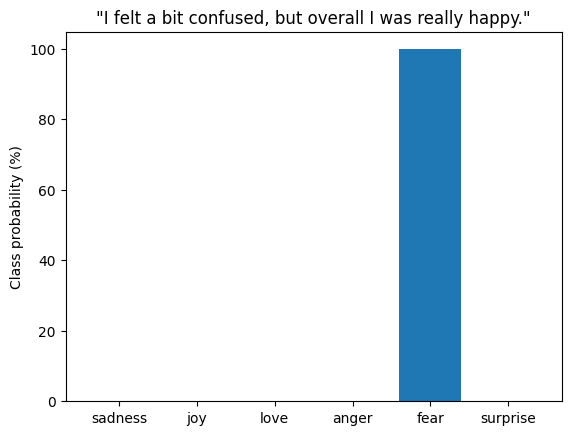

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

labels = emotions["train"].features["label"].names

preds_df = pd.DataFrame(preds[0])
plt.bar(labels, 100 * preds_df["score"], color='C0')
plt.title(f'"{custom_tweet}"')
plt.ylabel("Class probability (%)")
plt.show()